In [11]:
import pandas as pd 
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.preprocessing import StandardScaler


In [3]:
# 1: 
du_lieu = load_iris()
df = pd.DataFrame(du_lieu.data, columns= du_lieu.feature_names)


In [9]:
#2: 
print("Kích thước dữ liệu là: ", df.shape)
print("Tên các đặc trưng của bộ dữ liệu là: \n",du_lieu.feature_names)
print("Tên nhãn của bộ dữ liệu là: \n", du_lieu.target_names)

Kích thước dữ liệu là:  (150, 4)
Tên các đặc trưng của bộ dữ liệu là: 
 ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Tên nhãn của bộ dữ liệu là: 
 ['setosa' 'versicolor' 'virginica']


In [13]:
# 3 - 4
X = du_lieu.data 
y = du_lieu.target
chuan_hoa = StandardScaler()
x_chuan_hoa= chuan_hoa.fit_transform(X)

In [15]:
# 5. Áp dụng K-Means:
# o KMeans(n_clusters=3, random_state=42)
# o Lấy nhãn cụm bằng fit_predict().
mo_hinh_kmean = KMeans(n_clusters=3, random_state=42)
cum_kmean = mo_hinh_kmean.fit_predict(x_chuan_hoa)
print("Nhãn cụm K-Means:")
print(cum_kmean)

Nhãn cụm K-Means:
[1 2 2 2 1 1 1 1 2 2 1 1 2 2 1 1 1 1 1 1 1 1 1 1 1 2 1 1 1 2 2 1 1 1 2 2 1
 1 2 1 1 2 2 1 1 2 1 2 1 1 0 0 0 0 0 0 0 2 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0]


In [16]:
mo_hinh_DBscan = DBSCAN(eps= 0.5, min_samples=5)
cum_DBscan = mo_hinh_DBscan.fit_predict(x_chuan_hoa)
print("Nhan cum DBSCAN")
print(cum_DBscan)


Nhan cum DBSCAN
[ 0  0  0  0  0  0  0  0  0  0  0  0  0  0 -1 -1  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0 -1 -1  0  0  0  0  0  0  0 -1  0  0  0  0  0  0
  0  0  1  1  1  1  1  1 -1 -1  1 -1 -1  1 -1  1  1  1  1  1 -1  1  1  1
 -1  1  1  1  1  1  1  1  1  1  1  1  1 -1  1 -1  1  1  1  1  1 -1  1  1
  1  1 -1  1 -1  1  1  1  1 -1 -1 -1 -1 -1  1  1  1  1 -1  1  1 -1 -1 -1
  1  1 -1  1  1 -1  1  1  1 -1 -1 -1  1  1  1 -1 -1  1  1  1  1  1  1  1
  1  1  1  1 -1  1]


In [19]:
# 7 đánh giá kết quả 
print("Bộ chỉ số của mô hình KMEAN")
silhouette_kmean = silhouette_score(x_chuan_hoa, cum_kmean)
ari_kmean = adjusted_rand_score(y, cum_kmean)
print("silhouette_score : ", silhouette_kmean)
print("adjusted_rand_score: ", ari_kmean)
#########
print("Bộ chỉ số của mô hình DBSCAN")
silhouette_dbsca = silhouette_score(x_chuan_hoa, cum_DBscan)
ari_dbscan = adjusted_rand_score(y, cum_DBscan)
print("silhouette_score : ", silhouette_dbsca)
print("adjusted_rand_score: ", ari_dbscan)

Bộ chỉ số của mô hình KMEAN
silhouette_score :  0.4798814508199817
adjusted_rand_score:  0.432804702527474
Bộ chỉ số của mô hình DBSCAN
silhouette_score :  0.35651648142700726
adjusted_rand_score:  0.4420986685885924


In [20]:
# 8 
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
x_2d = pca.fit_transform(x_chuan_hoa)

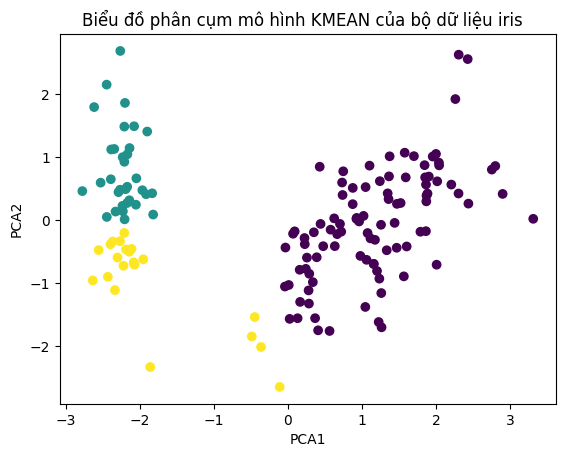

In [22]:
# 9 Vẽ biểu đồ pca của KMEAN 
import matplotlib.pyplot as plt
plt.scatter(x_2d[: ,0], x_2d[: , 1], c=cum_kmean)
plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.title("Biểu đồ phân cụm mô hình KMEAN của bộ dữ liệu iris  ")
plt.show()

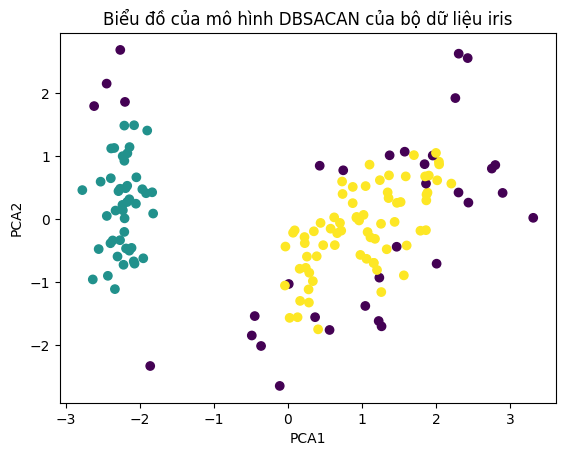

In [23]:
# Biểu đồ phân cụm của DBSCAN 
plt.scatter(x_2d[:,0], x_2d[:,1], c= cum_DBscan)
plt.title("Biểu đồ của mô hình DBSACAN của bộ dữ liệu iris")
plt.ylabel("PCA2")
plt.xlabel("PCA1")
plt.show()